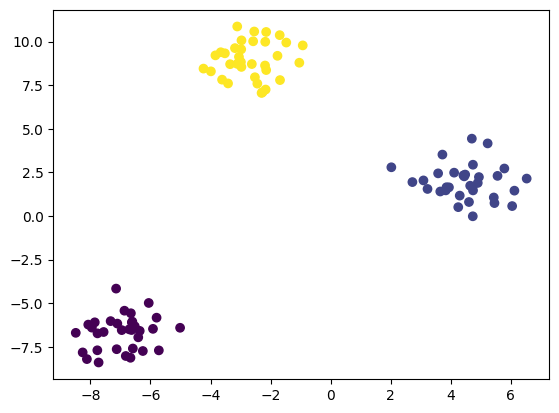

In [18]:
import numpy as np
from sklearn.datasets import make_blobs
from scipy.spatial.distance import cdist
from sklearn.cluster import AgglomerativeClustering

from matplotlib import pyplot as plt

# --- Zufällige Datenmatrix ---
np.random.seed(420)
X, y = make_blobs(n_samples=100, n_features=2, centers=3, random_state=42)

# --- Visualisierung ---
# plt.scatter(*X.T, c=y)
# plt.show()

# --- Distanzmatrix ---
d = cdist(X, X)

# --- Erstelle n Cluster ---
y = np.array(range(X.shape[0]))

K = 3
while True:
    # --- Performance ---
    C = np.unique(y)

    # --- Widerhole bis K-Cluster ---
    if C.shape[0] <= K:
        break

    # --- Unterschiedlichkeitsmaß (Average Linkage) ---
    linkage = np.array([[d[y==i][:,y==j].mean() if i!=j else np.inf for j in C] for i in C])
    # Alternativ: Complete Linkage
    # linkage = np.array([[d[y==i][:,y==j].max() if i!=j else np.inf for j in C] for i in C])
    # Alternativ: Single Linkage
    # linkage = np.array([[d[y==i][:,y==j].min() if i!=j else np.inf for j in C] for i in C])

    # --- Kombiniere gleichartige Cluster ---
    idx = linkage.argmin()
    i = idx % C.shape[0]
    j = idx // C.shape[0]
    
    y[y==C[i]] = C[j]

# --- Visualisierung ---
# plt.scatter(*X.T, c=y)
# plt.show()